In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, json as _json

from sklearn.model_selection import train_test_split
from sklearn.metrics         import (f1_score, recall_score, precision_score,
                                     roc_auc_score, classification_report,
                                     confusion_matrix, RocCurveDisplay,
                                     precision_recall_curve)
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
import xgboost as xgb
from imblearn.over_sampling  import SMOTE


Mesurer le déséquilibre

In [2]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Shape : {df.shape}")
print(f"info : {df.info()}")
print(f"colonnes : {df.columns.tolist()}")
print("\n head :", df.head(5))
print("\n description :", df.describe())


Shape : (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

Repartition des classes :
Class
0    284315
1       492
Name: count, dtype: int64
Pourcentage de fraudes : 0.1727%


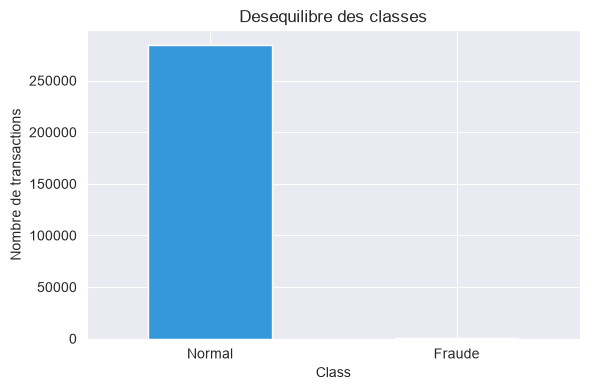

Graphique sauvegarde


In [3]:
os.makedirs("../outputs", exist_ok=True)
classes = df["Class"].value_counts()
print("Repartition des classes :")
print(classes)
perc = df["Class"].mean()*100
print(f"Pourcentage de fraudes : {perc:.4f}%")

fig, ax = plt.subplots(figsize=(6, 4))
classes.plot(kind="bar", ax=ax, color=["#3498db","#e74c3c"])
ax.set_xticks([0, 1])
ax.set_xticklabels(["Normal", "Fraude"], rotation=0)
ax.set_title("Desequilibre des classes")
ax.set_ylabel("Nombre de transactions")
plt.tight_layout()
fig.savefig("../outputs/desequilibre_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegarde")

Le piège de l'accuracy

In [4]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modèle naïf : toujours prédire "normal"
y_naive = np.zeros(len(y_test))
print(" Modèle naïf (toujours 0) ")
print(f"Accuracy : {(y_naive == y_test).mean():.4f}")
print(f"F1-Score : {f1_score(y_test, y_naive, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_naive, zero_division=0):.4f}")
print(" Accuracy parfaite = modèle parfaitement inutile")

 Modèle naïf (toujours 0) 
Accuracy : 0.9983
F1-Score : 0.0000
Recall   : 0.0000
 Accuracy parfaite = modèle parfaitement inutile


 Technique 1 : class_weight

In [5]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio 0/1 : {ratio:.0f}")

pipe_standard = Pipeline([
    ("scaler", StandardScaler()),
    ("modele", xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)),
])
pipe_spw = Pipeline([
    ("scaler", StandardScaler()),
    ("modele", xgb.XGBClassifier(n_estimators=100, random_state=42,
                                  scale_pos_weight=ratio, verbosity=0)),
])

for nom, pipe in [("XGBoost standard", pipe_standard),
                   ("scale_pos_weight",  pipe_spw)]:
    pipe.fit(X_train, y_train)
    yp  = pipe.predict(X_test)
    ypr = pipe.predict_proba(X_test)[:, 1]
    print(f"{nom:<28} F1={f1_score(y_test,yp):.4f}"
          f"  Recall={recall_score(y_test,yp):.4f}"
          f"  AUC={roc_auc_score(y_test,ypr):.4f}")

y_prob_spw = pipe_spw.predict_proba(X_test)[:, 1]


Ratio 0/1 : 577
XGBoost standard             F1=0.8254  Recall=0.7959  AUC=0.9277
scale_pos_weight             F1=0.8586  Recall=0.8367  AUC=0.9662


Technique 2 : SMOTE

In [6]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
vals, cnts = np.unique(y_resampled, return_counts=True)
print(f"Apres SMOTE : {dict(zip(vals.tolist(), cnts.tolist()))}")

pipe_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("modele", xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)),
])
pipe_smote.fit(X_resampled, y_resampled)
y_pred_smote = pipe_smote.predict(X_test)
y_prob_smote = pipe_smote.predict_proba(X_test)[:, 1]

print(f"SMOTE : F1={f1_score(y_test,y_pred_smote):.4f}"
       f"  Recall={recall_score(y_test,y_pred_smote):.4f}"
       f"  AUC={roc_auc_score(y_test,y_prob_smote):.4f}")


Avant SMOTE : {0: 227451, 1: 394}
Apres SMOTE : {0: 227451, 1: 227451}
SMOTE : F1=0.8431  Recall=0.8776  AUC=0.9827


Ajuster le seuil de décision

Comparaison finale des 4 strategies
  XGBoost standard         F1=0.8254
  scale_pos_weight         F1=0.8586
  SMOTE                    F1=0.8431
  scale_pos_weight+seuil   F1=0.8729   (OPTIMAL)
  SMOTE+seuil              F1=0.8681
Seuil optimal retenu : 0.962


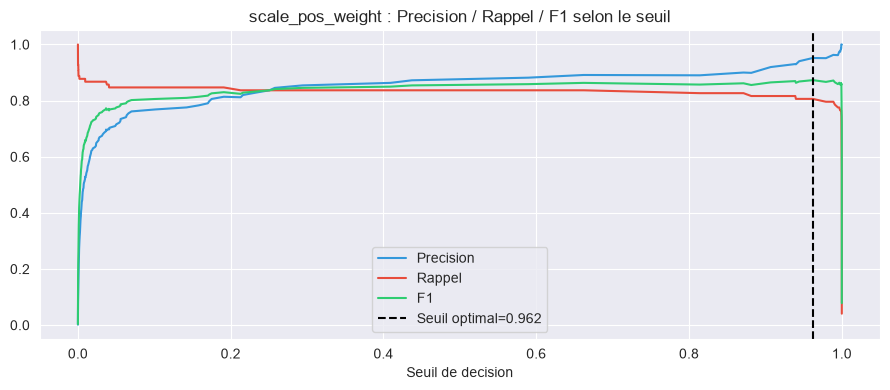

In [10]:
pre_spw, rec_spw, seu_spw = precision_recall_curve(y_test, y_prob_spw)
f1_spw = 2*(pre_spw*rec_spw)/(pre_spw+rec_spw+1e-10)
seuil_opt = seu_spw[f1_spw[:-1].argmax()]
y_pred_opt = (y_prob_spw >= seuil_opt).astype(int)

pre_sm, rec_sm, seu_sm = precision_recall_curve(y_test, y_prob_smote)
f1_sm = 2*(pre_sm*rec_sm)/(pre_sm+rec_sm+1e-10)
seuil_sm = seu_sm[f1_sm[:-1].argmax()]
y_pred_opt_sm = (y_prob_smote >= seuil_sm).astype(int)

print("Comparaison finale des 4 strategies")
print(f"  XGBoost standard         F1={f1_score(y_test, pipe_standard.predict(X_test)):.4f}")
print(f"  scale_pos_weight         F1={f1_score(y_test, pipe_spw.predict(X_test)):.4f}")
print(f"  SMOTE                    F1={f1_score(y_test, y_pred_smote):.4f}")
print(f"  scale_pos_weight+seuil   F1={f1_score(y_test, y_pred_opt):.4f}   (OPTIMAL)")
print(f"  SMOTE+seuil              F1={f1_score(y_test, y_pred_opt_sm):.4f}")
print(f"Seuil optimal retenu : {seuil_opt:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(seu_spw, pre_spw[:-1], label="Precision", color="#3498db")
ax.plot(seu_spw, rec_spw[:-1], label="Rappel",    color="#e74c3c")
ax.plot(seu_spw, f1_spw[:-1],  label="F1",        color="#2ecc71")
ax.axvline(seuil_opt, color="black", linestyle="--",
           label=f"Seuil optimal={seuil_opt:.3f}")
ax.set_xlabel("Seuil de decision")
ax.set_title("scale_pos_weight : Precision / Rappel / F1 selon le seuil")
ax.legend()
plt.tight_layout()
fig.savefig("../outputs/courbe_seuil_optimal.png", dpi=150, bbox_inches="tight")
plt.show()


## Matrice de confusion et Courbe ROC

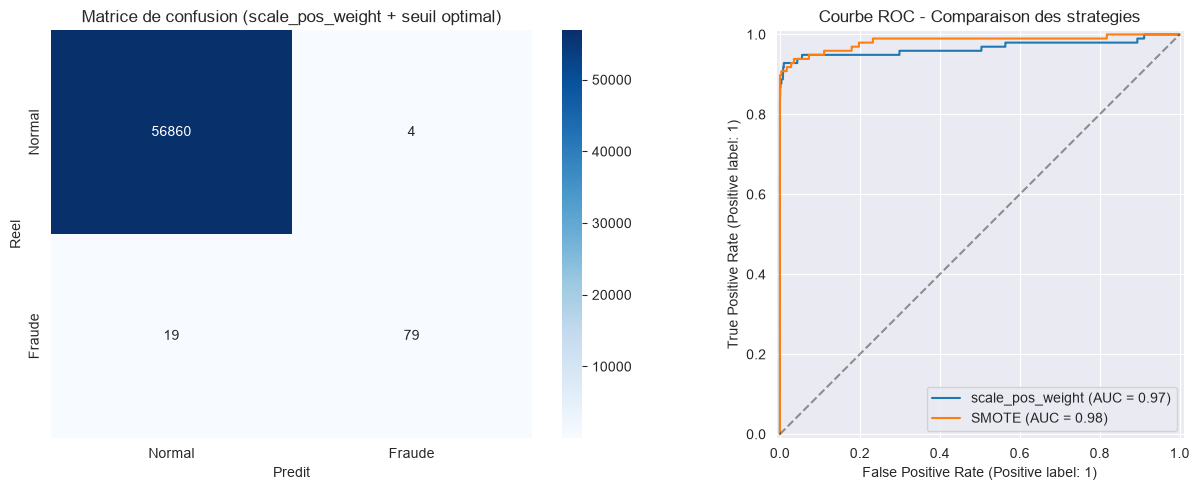

Rapport de classification (scale_pos_weight + seuil optimal) :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.95      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal","Fraude"], yticklabels=["Normal","Fraude"])
axes[0].set_ylabel("Reel")
axes[0].set_xlabel("Predit")
axes[0].set_title("Matrice de confusion (scale_pos_weight + seuil optimal)")

RocCurveDisplay.from_predictions(y_test, y_prob_spw,   ax=axes[1], name="scale_pos_weight")
RocCurveDisplay.from_predictions(y_test, y_prob_smote, ax=axes[1], name="SMOTE")
axes[1].plot([0,1],[0,1],"k--",alpha=0.4)
axes[1].set_title("Courbe ROC - Comparaison des strategies")

plt.tight_layout()
fig.savefig("../outputs/confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print("Rapport de classification (scale_pos_weight + seuil optimal) :")
print(classification_report(y_test, y_pred_opt, target_names=["Normal","Fraude"]))


## Sauvegarde des modeles et des graphiques

In [12]:
os.makedirs("../models", exist_ok=True)

joblib.dump(pipe_standard, "../models/xgb_standard.pkl")
joblib.dump(pipe_spw,      "../models/xgb_scale_pos_weight.pkl")
joblib.dump(pipe_smote,    "../models/xgb_smote.pkl")

with open("../models/seuil_optimal.json", "w") as f:
    _json.dump({"seuil": float(seuil_opt),
               "modele": "xgb_scale_pos_weight.pkl"}, f, indent=2)

print("Modeles sauvegardes :")
print("  xgb_standard.pkl")
print("  xgb_scale_pos_weight.pkl")
print("  xgb_smote.pkl")
print("  seuil_optimal.json")

import glob
pngs = [p.replace(chr(92),"/").split("/")[-1] for p in glob.glob("../outputs/*.png")]
print("Graphiques outputs/ :", pngs)


Modeles sauvegardes :
  xgb_standard.pkl
  xgb_scale_pos_weight.pkl
  xgb_smote.pkl
  seuil_optimal.json
Graphiques outputs/ : ['confusion_roc.png', 'courbe_seuil_optimal.png', 'desequilibre_classes.png']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal","Fraude"], yticklabels=["Normal","Fraude"])
axes[0].set_ylabel("Reel")
axes[0].set_xlabel("Predit")
axes[0].set_title("Matrice de confusion (scale_pos_weight + seuil optimal)")

RocCurveDisplay.from_predictions(y_test, y_prob_spw,   ax=axes[1], name="scale_pos_weight")
RocCurveDisplay.from_predictions(y_test, y_prob_smote, ax=axes[1], name="SMOTE")
axes[1].plot([0,1],[0,1],"k--",alpha=0.4)
axes[1].set_title("Courbe ROC - Comparaison des strategies")

plt.tight_layout()
fig.savefig("../outputs/confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print("Rapport de classification (scale_pos_weight + seuil optimal) :")
print(classification_report(y_test, y_pred_opt, target_names=["Normal","Fraude"]))


## Sauvegarde des modeles et des graphiques

In [ ]:
os.makedirs("../models", exist_ok=True)

joblib.dump(pipe_standard, "../models/xgb_standard.pkl")
joblib.dump(pipe_spw,      "../models/xgb_scale_pos_weight.pkl")
joblib.dump(pipe_smote,    "../models/xgb_smote.pkl")

with open("../models/seuil_optimal.json", "w") as f:
    _json.dump({"seuil": float(seuil_opt),
               "modele": "xgb_scale_pos_weight.pkl"}, f, indent=2)

print("Modeles sauvegardes :")
print("  xgb_standard.pkl")
print("  xgb_scale_pos_weight.pkl")
print("  xgb_smote.pkl")
print("  seuil_optimal.json")

import glob
pngs = [p.replace(chr(92),"/").split("/")[-1] for p in glob.glob("../outputs/*.png")]
print("Graphiques outputs/ :", pngs)
